In [1]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-06-21 14:11:14--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.003s  

2026-06-21 14:11:14 (72.3 MB/s) - ‘names.txt’ saved [228145/228145]



In [2]:
 words=open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(i) for i in words)

2

In [5]:
max(len(i) for i in words)

15

In [6]:
'''for w in words:
  if len(w) == max(len(i) for i in words):
    print(w)'''

'for w in words:\n  if len(w) == max(len(i) for i in words):\n    print(w)'

In [7]:
'''for w in words:
  if len(w) == min(len(i) for i in words):
    print(w)'''

'for w in words:\n  if len(w) == min(len(i) for i in words):\n    print(w)'

In [8]:
import torch
N = torch.zeros((27,27), dtype=torch.int32)

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [10]:

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

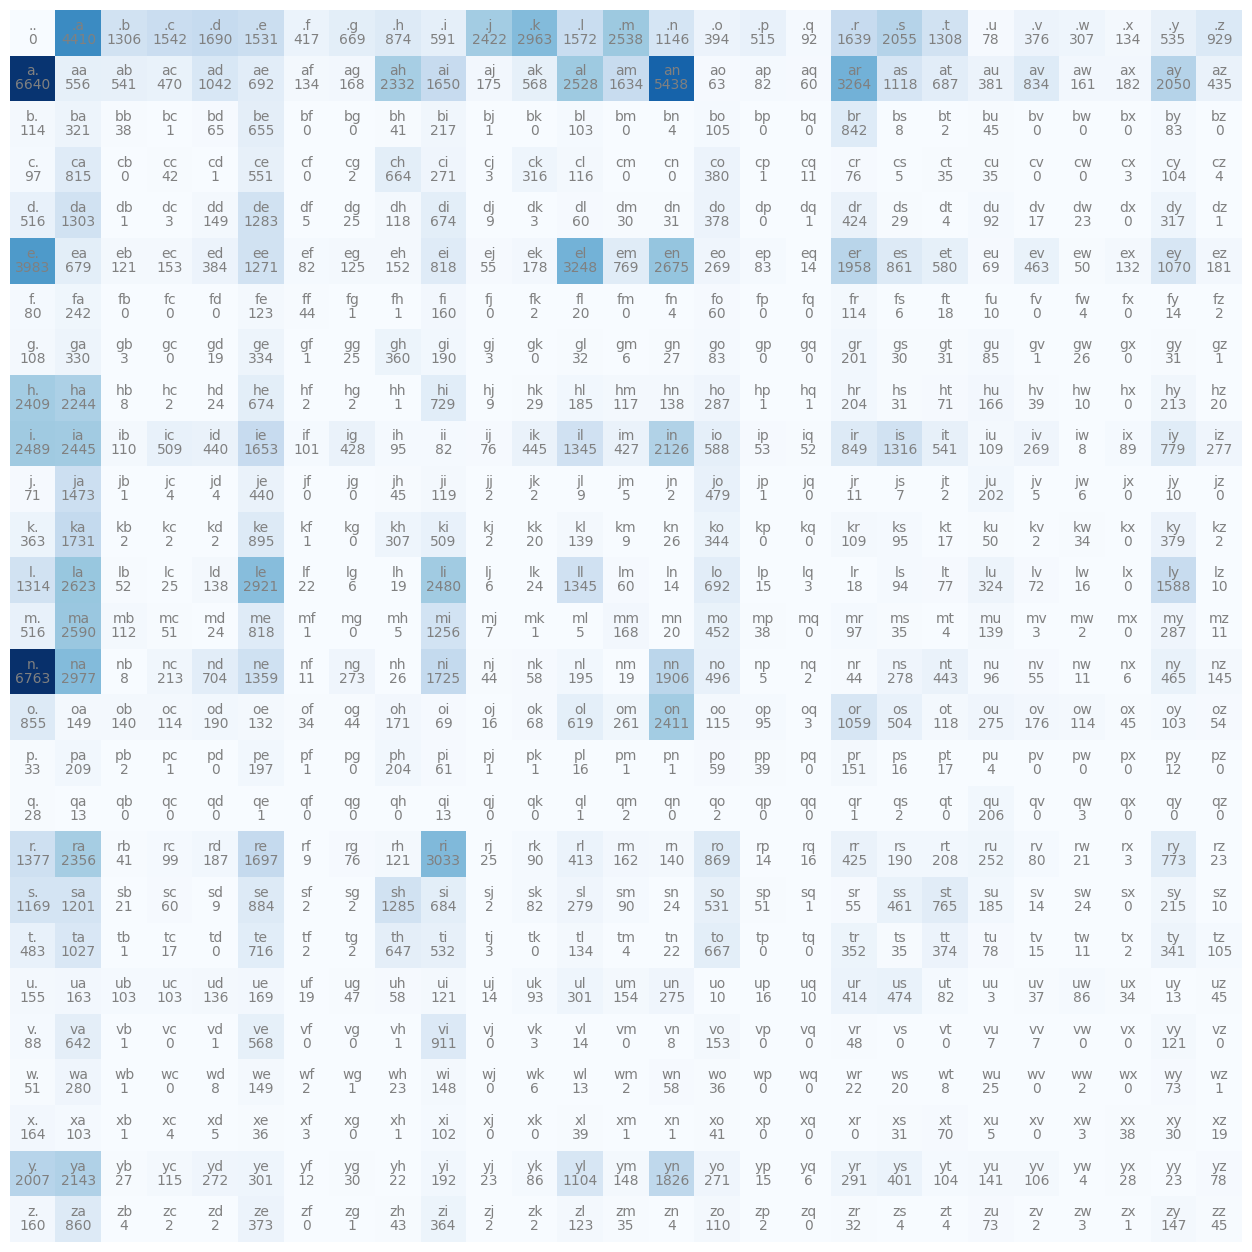

In [11]:

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [12]:
p=N[0].float()
p= p/p.sum()
g=torch.Generator().manual_seed(219998084195)
ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g)
itos[ix.item()]

'z'

In [13]:
P=(N+1).float()
P=P/P.sum(1,keepdim=True)
P[3].sum()

tensor(1.)

In [14]:
g=torch.Generator().manual_seed(219998094195)
for i in range(2):
  ix=0
  out=[]

  while True:
    p=P[ix]

    ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    out.append(itos[ix])

    if ix==0:
      break
  print(''.join(out))

aletan.
aeva.


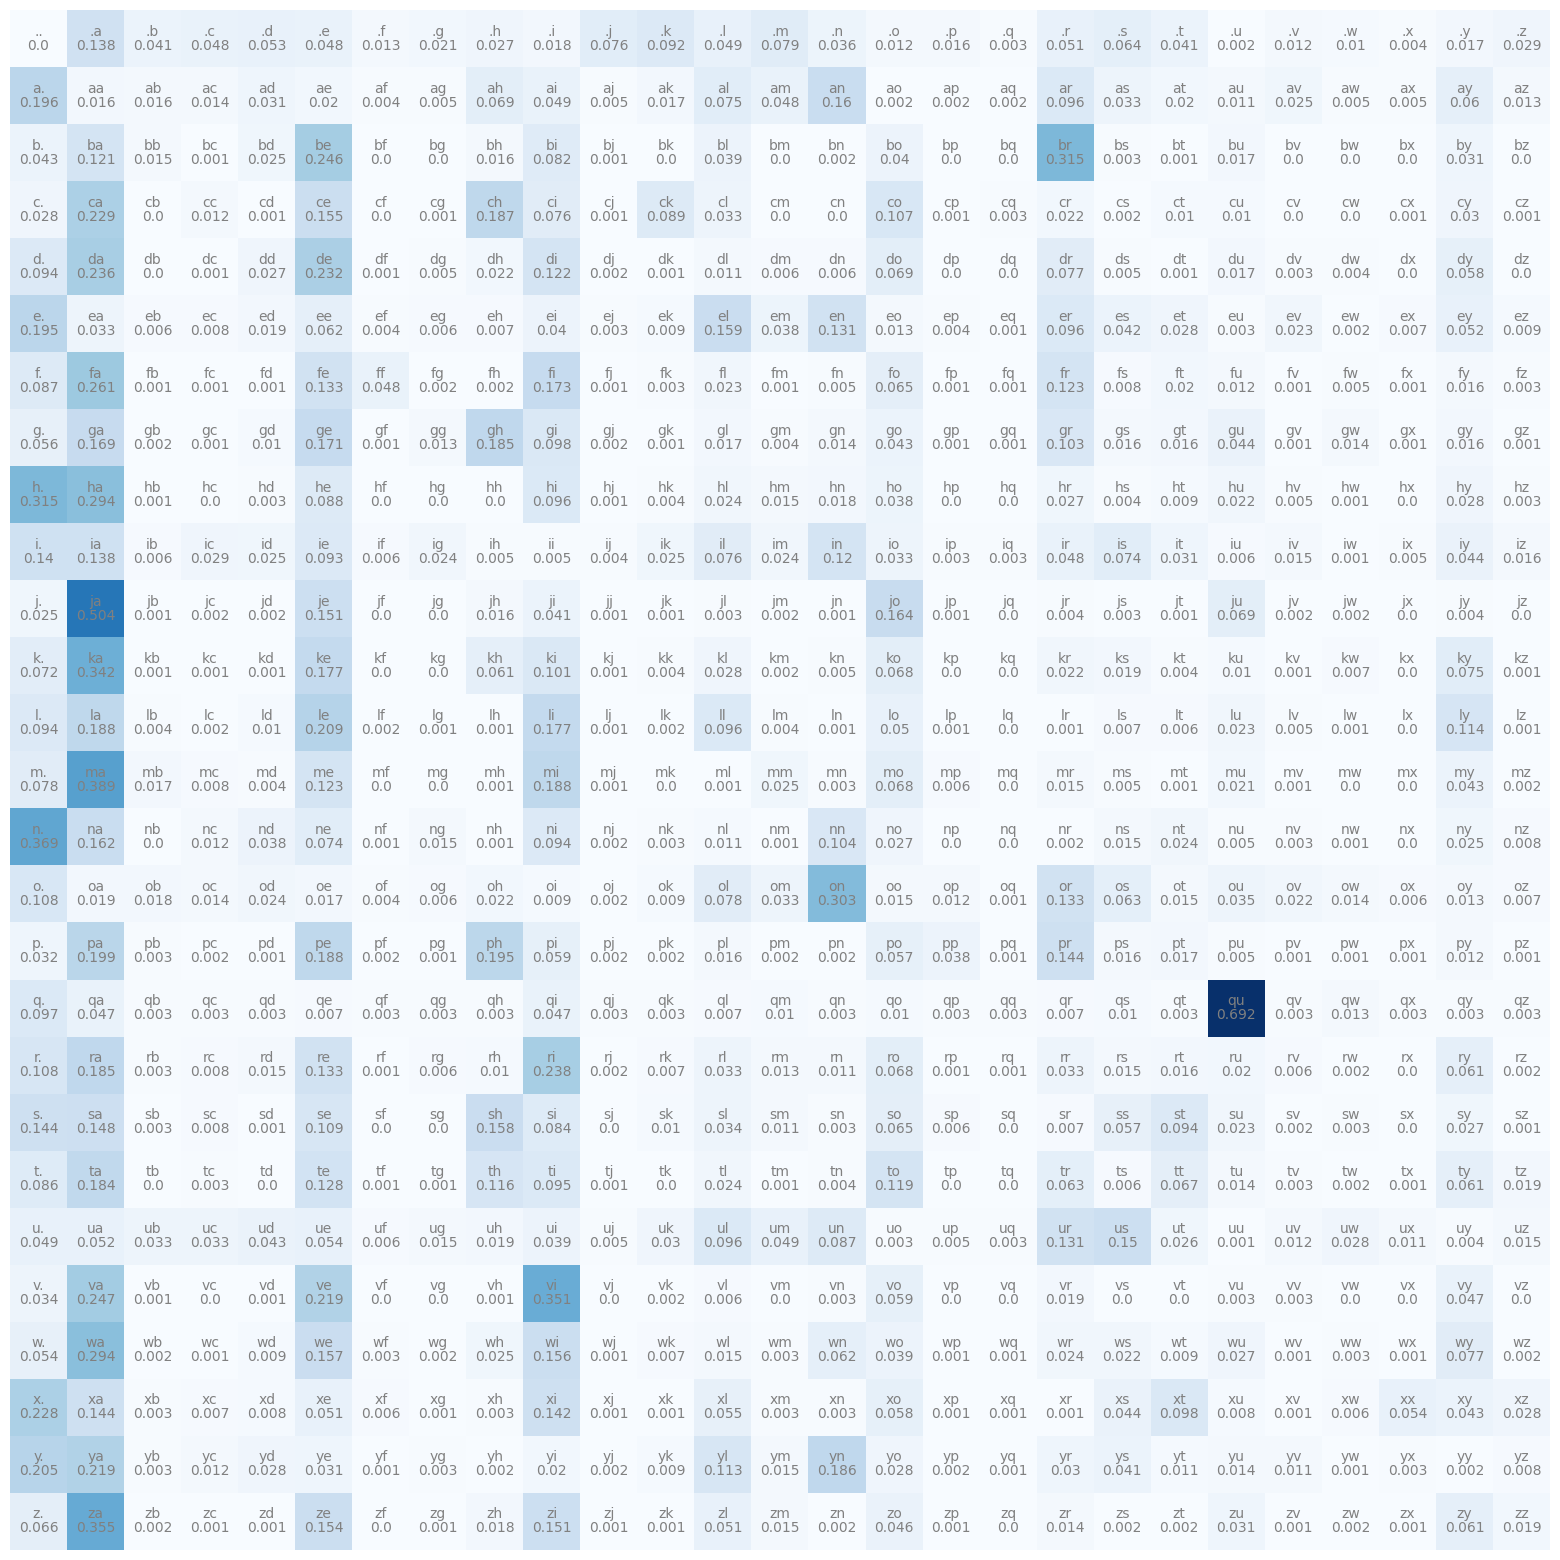

In [15]:
plt.figure(figsize=(20,20))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, round(P[i, j].item(),3), ha="center", va="top", color='gray')
plt.axis('off');

In [16]:
n=0
log_likelihood=0
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob=P[ix1,ix2]
    logprob=torch.log(prob)
    log_likelihood+=logprob
    n+=1
    print(f'{ch1,ch2} : {prob:.3f} : {logprob:.3f}:')

print(log_likelihood) #maximise this
nll=-log_likelihood
normalised_nll= nll/n #value of normalised nll is loss function and it should be minimised in order to reduce the loss
print(normalised_nll)

Streaming output truncated to the last 5000 lines.
('s', 'e') : 0.109 : -2.218:
('e', 'n') : 0.131 : -2.034:
('n', 'r') : 0.002 : -6.011:
('r', 'i') : 0.238 : -1.434:
('i', 'q') : 0.003 : -5.813:
('q', 'u') : 0.692 : -0.368:
('u', 'e') : 0.054 : -2.923:
('e', '.') : 0.195 : -1.636:
('.', 'l') : 0.049 : -3.015:
('l', 'u') : 0.023 : -3.762:
('u', 'i') : 0.039 : -3.255:
('i', 's') : 0.074 : -2.600:
('s', 'm') : 0.011 : -4.493:
('m', 'i') : 0.188 : -1.669:
('i', 'g') : 0.024 : -3.721:
('g', 'u') : 0.044 : -3.123:
('u', 'e') : 0.054 : -2.923:
('e', 'l') : 0.159 : -1.840:
('l', '.') : 0.094 : -2.364:
('.', 'l') : 0.049 : -3.015:
('l', 'u') : 0.023 : -3.762:
('u', 'k') : 0.030 : -3.516:
('k', 'm') : 0.002 : -6.228:
('m', 'a') : 0.389 : -0.945:
('a', 'n') : 0.160 : -1.830:
('n', '.') : 0.369 : -0.998:
('.', 'l') : 0.049 : -3.015:
('l', 'u') : 0.023 : -3.762:
('u', 'n') : 0.087 : -2.439:
('n', 'a') : 0.162 : -1.819:
('a', '.') : 0.196 : -1.631:
('.', 'l') : 0.049 : -3.015:
('l', 'u') : 0.023 : 

**MAIN PART STARTS HERE HHOOHOHOHOHOWOWOWOWO**

In [17]:
#creating the training set of bigrams
xs,ys = [],[]

for w in words:
  chs= ['.']+list(w)+['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    ix1=stoi[ch1]
    ix2=stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num=xs.nelement()
print('number of examples:',num)

number of examples: 228146


In [18]:
import torch.nn.functional as F


In [19]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [20]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [21]:
g=torch.Generator().manual_seed(2147571725)
W = torch.randn((27,27),generator=g, requires_grad= True)

In [22]:
for k in range(100):

#forward pass
  xenc= F.one_hot(xs,num_classes=27).float()
  logits = xenc @ W
  counts = logits.exp()
  probs = counts/counts.sum(1,keepdim=True)
  loss=-probs[torch.arange(num),ys].log().mean()
  print(loss.item())

  # backward pass
  W.grad = None
  loss.backward()

  #update
  W.data += -69*W.grad


3.77640438079834
3.288581132888794
3.0348379611968994
2.897416830062866
2.808955430984497
2.748447895050049
2.705256462097168
2.673041820526123
2.6481425762176514
2.62827205657959
2.6119470596313477
2.5982134342193604
2.5864593982696533
2.576279640197754
2.567389726638794
2.559579610824585
2.552685022354126
2.5465714931488037
2.5411269664764404
2.536257028579712
2.531881332397461
2.527933120727539
2.52435302734375
2.5210931301116943
2.51811146736145
2.515373468399048
2.5128493309020996
2.5105135440826416
2.508345365524292
2.5063257217407227
2.50443959236145
2.502673387527466
2.5010154247283936
2.4994559288024902
2.497985363006592
2.4965968132019043
2.4952831268310547
2.4940383434295654
2.492856740951538
2.491734743118286
2.490666627883911
2.489649534225464
2.4886794090270996
2.487753391265869
2.4868690967559814
2.486023426055908
2.4852144718170166
2.4844396114349365
2.4836971759796143
2.482985019683838
2.482301950454712
2.4816460609436035
2.481015920639038
2.4804108142852783
2.47982859

In [23]:
loss

tensor(2.4665, grad_fn=<NegBackward0>)

In [24]:
W

tensor([[-3.0258e+00,  1.9795e+00,  7.6189e-01,  9.2816e-01,  1.0199e+00,
          9.2100e-01, -3.8229e-01,  9.1874e-02,  3.5970e-01, -3.2401e-02,
          1.3800e+00,  1.5817e+00,  9.4745e-01,  1.4268e+00,  6.3104e-01,
         -4.3928e-01, -1.7045e-01, -1.8940e+00,  9.8922e-01,  1.2156e+00,
          7.6342e-01, -2.0144e+00, -4.8625e-01, -6.9011e-01, -1.5160e+00,
         -1.3223e-01,  4.2082e-01],
        [ 2.0440e+00, -4.3726e-01, -4.6465e-01, -6.0559e-01,  1.9152e-01,
         -2.1815e-01, -1.8615e+00, -1.6404e+00,  9.9746e-01,  6.5139e-01,
         -1.5974e+00, -4.1587e-01,  1.0782e+00,  6.4165e-01,  1.8443e+00,
         -2.5006e+00, -2.3133e+00, -2.5695e+00,  1.3338e+00,  2.6196e-01,
         -2.2541e-01, -8.1603e-01, -3.1318e-02, -1.6786e+00, -1.5571e+00,
          8.6853e-01, -6.8314e-01],
        [ 8.7414e-01,  2.0113e+00, -4.8926e-01, -7.8427e-01,  2.4323e-01,
          2.7476e+00, -1.1909e+00, -2.1286e+00, -7.0926e-01,  1.5829e+00,
         -8.1325e-01, -1.2360e+00,  7.17

In [28]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(294074774)

for i in range(5):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

manan.
d.
jalesinine.
lilyn.
ssx.
